# 🧠 BigMart Sales Prediction - Linear Regression Model
This notebook demonstrates a **professional machine learning pipeline** for predicting sales using the **BigMart Sales dataset**.

---
## 🪜 Steps Covered
1. Import libraries
2. Load and inspect data
3. Handle missing values
4. Feature engineering
5. Encode categorical variables
6. Scale numerical features
7. Split dataset
8. Train Linear Regression model
9. Evaluate model performance
10. Save trained model

In [2]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Load dataset
df = pd.read_csv("bigmartsales-cleaned.csv")
df.head()


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,NaN,NaN,Grocery Store,732.3800,13.6
4,NCD19,8.93,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1


### 2️⃣ Handle Missing Values & Feature Engineering

In [3]:

# Fill missing numerical values with mean
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)

# Fill missing categorical values with mode
df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0], inplace=True)
df['Outlet_Location_Type'].fillna(df['Outlet_Location_Type'].mode()[0], inplace=True)

# Create new feature: Outlet_Age
df['Outlet_Age'] = 2020 - df['Outlet_Establishment_Year']

# Extract Item_Category from Item_Identifier
df['Item_Category'] = df['Item_Identifier'].apply(lambda x: x[:2])
df['Item_Category'] = df['Item_Category'].map({'FD': 'Food', 'DR': 'Drinks', 'NC': 'Non-Consumable'})

df.head()


/var/folders/6r/86jpjbx9667_wsdjbp1ln2rc0000gn/T/ipykernel_13753/573778430.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace=True)
/var/folders/6r/86jpjbx9667_wsdjbp1ln2rc0000gn/T/ipykernel_13753/573778430.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setti

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Profit,Outlet_Age,Item_Category
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8,OUT049,1999,Medium,Tier 2,Supermarket Type1,3735.1380,11.5,21,Food
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.3,OUT018,2009,Medium,Tier 2,Supermarket Type2,443.4228,14.3,11,Drinks
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6,OUT049,1999,Medium,Tier 2,Supermarket Type1,2097.2700,14.5,21,Food
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.1,OUT010,1998,Medium,Tier 2,Grocery Store,732.3800,13.6,22,Food
4,NCD19,8.93,Low Fat,0.000000,Household,53.9,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,14.1,33,Non-Consumable


### 3️⃣ Define Features and Target

In [4]:

X = df.drop(columns=['Item_Outlet_Sales'])
y = df['Item_Outlet_Sales']

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

cat_cols, num_cols


(Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
        'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category'],
       dtype='object'),
 Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
        'Outlet_Establishment_Year', 'Profit', 'Outlet_Age'],
       dtype='object'))

### 4️⃣ Preprocessing Pipeline

In [5]:

# Preprocessing for numerical and categorical columns
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)


### 5️⃣ Split Data and Train Model

In [6]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build pipeline with preprocessing and model
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('regressor', LinearRegression())])

# Train model
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Profit', 'Outlet_Age'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category'],
      dtype='object'))])),
                ('regressor', LinearRegression())])

### 6️⃣ Evaluate Model

In [7]:

# Predict
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluate
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print("Training RMSE:", rmse_train)
print("Testing RMSE:", rmse_test)
print("Training R2:", r2_train)
print("Testing R2:", r2_test)


Training RMSE: 996.6607630319063
Testing RMSE: 1272.4105909756183
Training R2: 0.6641934391400459
Testing R2: 0.4043243036733446


### 7️⃣ Save the Model

In [8]:

joblib.dump(model, "linear_model_bigmartsales.pkl")
print("✅ Model saved as linear_model_bigmartsales.pkl")


✅ Model saved as linear_model_bigmartsales.pkl


---
# 🚀 Advanced Regression Analysis (Option B)
We now extend the baseline Linear Regression model with **cross-validation**, **regularization**, and **visual diagnostics** for a more professional analysis.

### Added Features
- Ridge & Lasso Regression
- K-Fold Cross Validation
- Model Comparison
- Residual and Prediction Plots
- Feature Importance Visualization

### 8️⃣ Cross-Validation & Regularization Models

In [9]:

from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# Baseline Linear Regression
lr_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.001)

ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', ridge)])

lasso_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', lasso)])

ridge_scores = cross_val_score(ridge_pipeline, X, y, cv=5, scoring='r2')
lasso_scores = cross_val_score(lasso_pipeline, X, y, cv=5, scoring='r2')

print(f"Linear Regression CV R²: {lr_scores.mean():.4f}")
print(f"Ridge Regression CV R²:  {ridge_scores.mean():.4f}")
print(f"Lasso Regression CV R²:  {lasso_scores.mean():.4f}")


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3057879823.717517, tolerance: 1954866.4647094156
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2785795625.530007, tolerance: 2001724.4948117975
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3087951906.472089, tolerance: 2014946.6097111204
  model = cd_fast.sparse_enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_desce

Linear Regression CV R²: 0.4267
Ridge Regression CV R²:  0.4850
Lasso Regression CV R²:  0.4278


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 2809137181.773379, tolerance: 1971962.1232170938
  model = cd_fast.sparse_enet_coordinate_descent(


### 9️⃣ Model Comparison

In [10]:

results = pd.DataFrame({
    'Model': ['LinearRegression', 'Ridge', 'Lasso'],
    'CV_R2_Score': [lr_scores.mean(), ridge_scores.mean(), lasso_scores.mean()]
})
results.sort_values(by='CV_R2_Score', ascending=False)


,Model,CV_R2_Score
1,Ridge,0.485009
2,Lasso,0.427764
0,LinearRegression,0.426679


### 🔟 Residuals and Prediction Plots

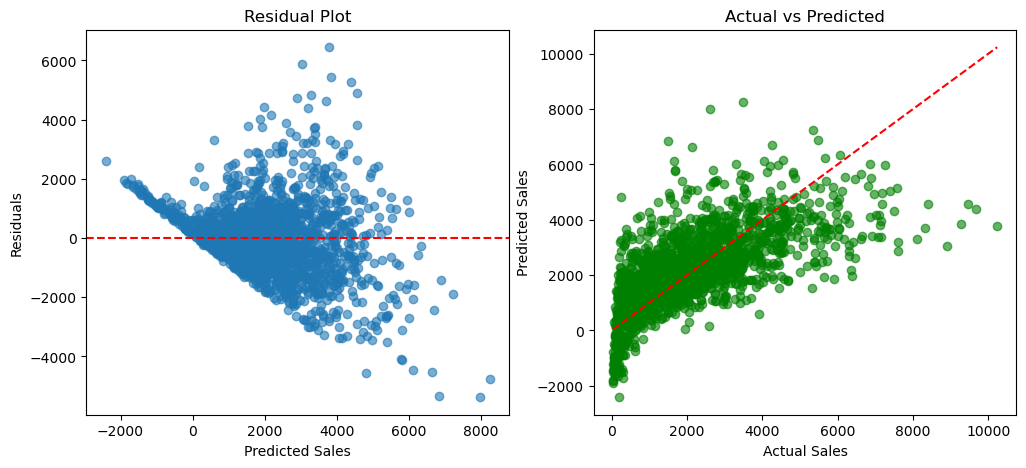

In [11]:

# Predictions
y_pred = model.predict(X_test)

# Residuals
residuals = y_test - y_pred

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()


### 1️⃣1️⃣ Feature Importance Visualization

<Figure size 1000x600 with 0 Axes>

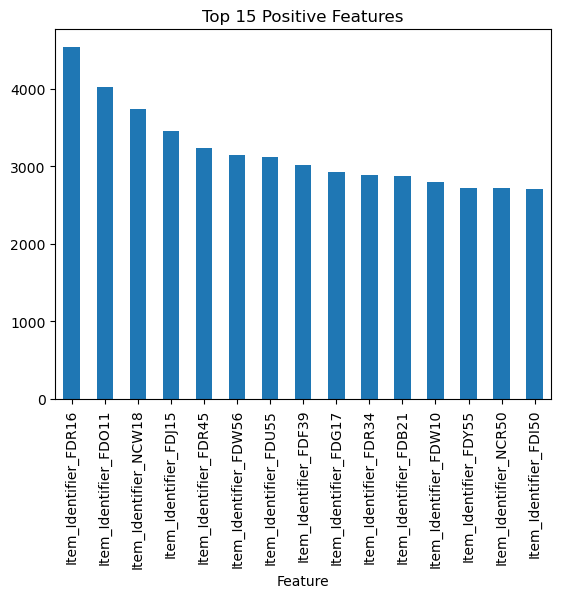

<Figure size 1000x600 with 0 Axes>

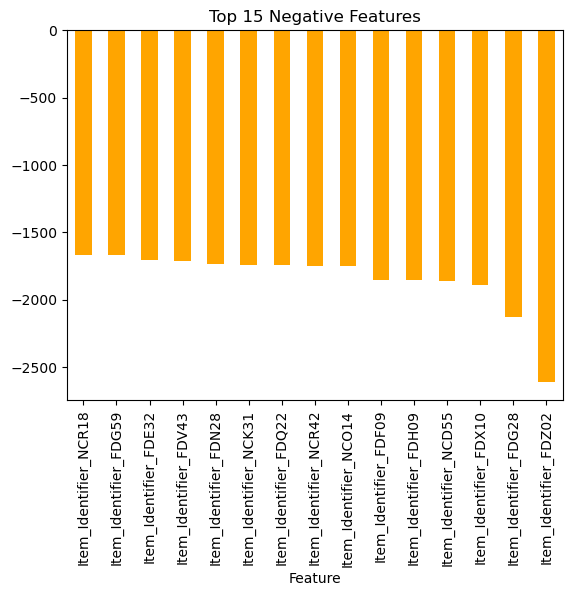

In [12]:

# Extract feature names after one-hot encoding
encoded_cols = list(preprocessor.transformers_[1][1]['onehot'].get_feature_names_out(cat_cols))
feature_names = list(num_cols) + encoded_cols

# Fit model again for coefficient extraction
final_model = model.named_steps['regressor']
preprocessor_fit = model.named_steps['preprocessor']
X_transformed = preprocessor_fit.transform(X_train)

coefs = final_model.coef_ if hasattr(final_model, 'coef_') else np.zeros(len(feature_names))
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs}).sort_values(by='Coefficient', ascending=False)

# Plot top 15 positive and negative features
plt.figure(figsize=(10,6))
coef_df.head(15).plot(kind='bar', x='Feature', y='Coefficient', legend=False, title='Top 15 Positive Features')
plt.show()

plt.figure(figsize=(10,6))
coef_df.tail(15).plot(kind='bar', x='Feature', y='Coefficient', legend=False, title='Top 15 Negative Features', color='orange')
plt.show()


✅ **Conclusion**
- Ridge and Lasso help reduce overfitting.
- Cross-validation gives a more reliable R² estimate.
- Residual plots show how errors are distributed.
- Feature importance visualization reveals which attributes drive sales the most.

This completes your **professional-level regression workflow** for BigMart Sales!